In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print(df.shape)

print(df.info())

print(df.describe())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

In [4]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [6]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


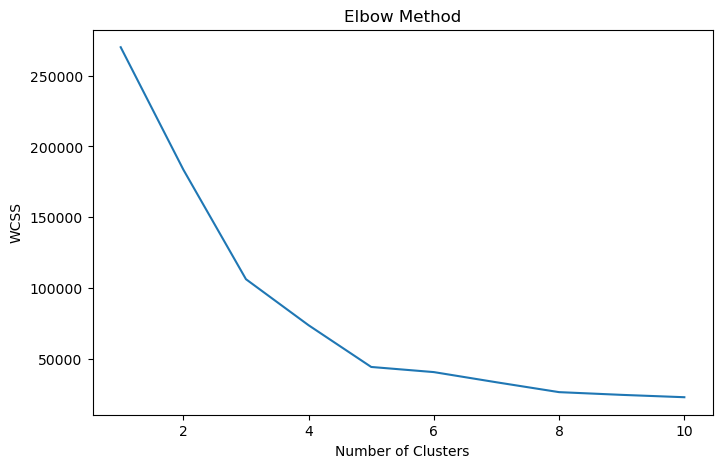

In [7]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [8]:
kmeans=KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y=kmeans.fit_predict(X)

df['Cluster']=y

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


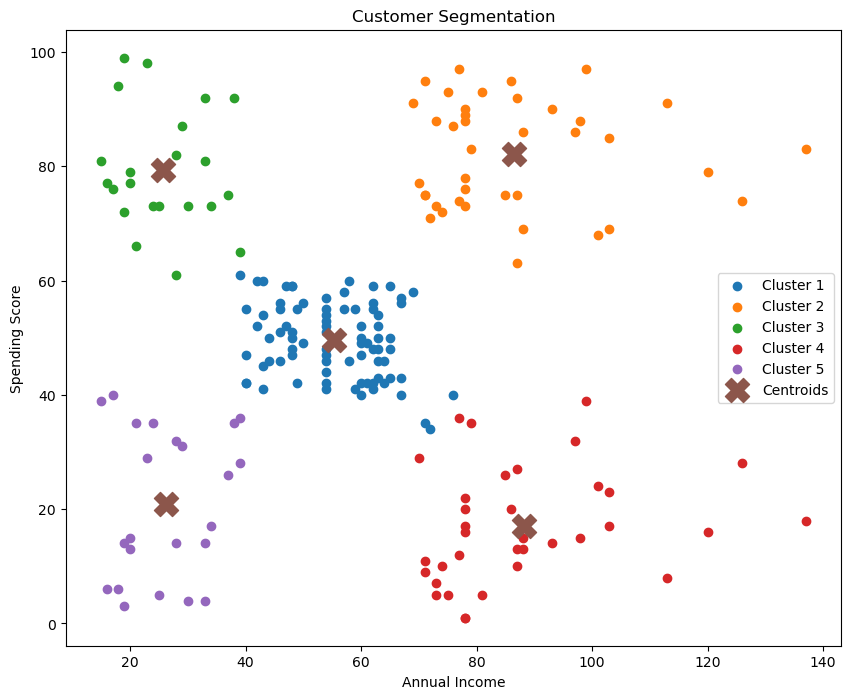

In [9]:
plt.figure(figsize=(10,8))

plt.scatter(
X.iloc[y==0,0],
X.iloc[y==0,1],
label='Cluster 1'
)

plt.scatter(
X.iloc[y==1,0],
X.iloc[y==1,1],
label='Cluster 2'
)

plt.scatter(
X.iloc[y==2,0],
X.iloc[y==2,1],
label='Cluster 3'
)

plt.scatter(
X.iloc[y==3,0],
X.iloc[y==3,1],
label='Cluster 4'
)

plt.scatter(
X.iloc[y==4,0],
X.iloc[y==4,1],
label='Cluster 5'
)

plt.scatter(
kmeans.cluster_centers_[:,0],
kmeans.cluster_centers_[:,1],
s=300,
marker='X',
label='Centroids'
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segmentation")

plt.legend()

plt.show()

In [10]:
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [11]:
cluster_analysis = df.groupby('Cluster').mean(
    numeric_only=True
)

print(cluster_analysis)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


In [12]:
df['Cluster']=y

In [13]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [14]:
cluster_summary = df.groupby('Cluster').agg({

'Age':'mean',

'Annual Income (k$)':'mean',

'Spending Score (1-100)':'mean'

})

print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [15]:
print(
pd.crosstab(
df['Cluster'],
df['Gender']
)
)

Gender   Female  Male
Cluster              
0            48    33
1            21    18
2            13     9
3            16    19
4            14     9


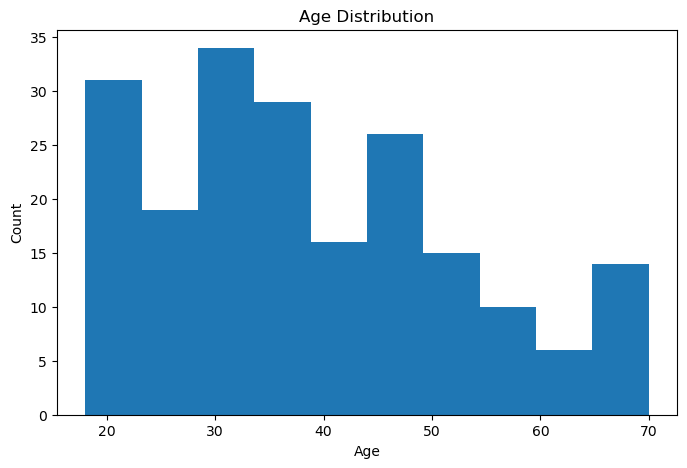

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'])

plt.xlabel("Age")

plt.ylabel("Count")

plt.title("Age Distribution")

plt.show()

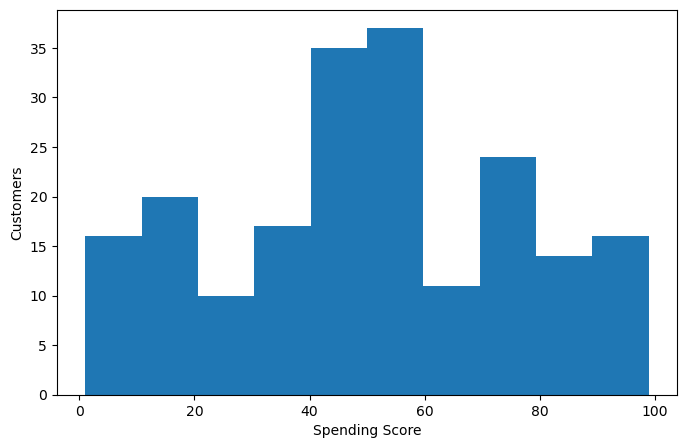

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
df['Spending Score (1-100)']
)

plt.xlabel("Spending Score")

plt.ylabel("Customers")

plt.show()

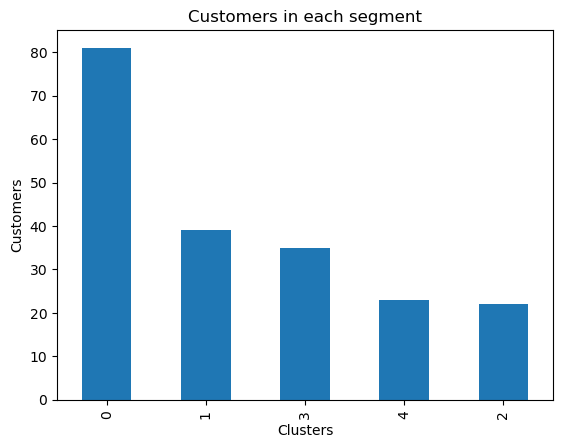

In [18]:
df['Cluster'].value_counts().plot(
kind='bar'
)

plt.xlabel("Clusters")

plt.ylabel("Customers")

plt.title(
"Customers in each segment"
)

plt.show()

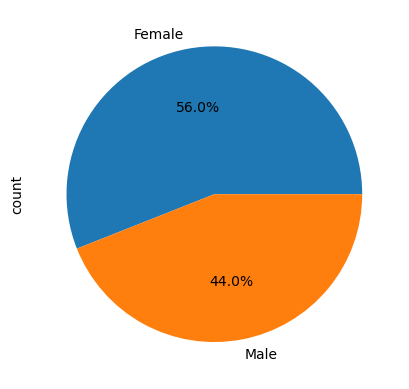

In [19]:
df['Gender'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.show()